# Notebook 05 — Results & Novelty Analysis (with Skeleton Views)

**Goal**: Explore all historical alpha results from DuckDB, including the new skeleton family trees:
- Pass rate over time / by direction
- Metric distributions (Sharpe, Fitness, Turnover, IC)
- Expression novelty distribution
- Failure reason analysis
- Expression clustering
- Bandit direction performance
- **NEW** Skeleton family tree: which skeleton spawned which qualified alphas
- **NEW** Per-skeleton output distribution
- **NEW** TrackBandit arm performance over time

**Requires**: Notebook 04 completed with at least a few simulation rounds.

In [1]:
import json
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

from alpha_agent.knowledge.alpha_memory import AlphaMemory
from alpha_agent.knowledge.skeleton_registry import SkeletonRegistry
from alpha_agent.knowledge.vector_store import VectorStore
from alpha_agent.search.bandit import DirectionBandit
from alpha_agent.search.novelty import NoveltyScorer

memory   = AlphaMemory()
registry = SkeletonRegistry()
store    = VectorStore()
bandit   = DirectionBandit(memory)

stats = memory.stats()
reg_stats = registry.stats()
print(f"Total alphas: {stats['total']} | Qualified: {stats['qualified']} | Pass rate: {stats['pass_rate']:.1%}")
print(f"Skeleton registry: {reg_stats['total']} total, {reg_stats['active']} active, {reg_stats['instances']} instances")

Total alphas: 6 | Qualified: 0 | Pass rate: 0.0%
Skeleton registry: 11 total, 11 active, 7 instances


## 1. Load all data from DuckDB

In [2]:
df = memory.to_dataframe()

# Parse metrics JSON
metrics_df = df['metrics_json'].apply(lambda x: json.loads(x) if x else {}).apply(pd.Series)
df = pd.concat([df.drop(columns=['metrics_json']), metrics_df], axis=1)

# Parse failure reasons
df['failure_reasons_list'] = df['failure_reasons'].apply(
    lambda x: json.loads(x) if x else []
)

print(f"Loaded {len(df)} rows")
display(df.head(5))

Loaded 6 rows


,id,expression,hypothesis,dataset,universe,checks_json,qualified,soft_qualified,skeleton_id,track,failure_reasons,reflection,embedding,created_at,sharpe,fitness,turnover,margin,checks,failure_reasons_list
0,XgY9joml,"group_rank(ts_std_dev(open, 100), sector)",,pv1,TOP1000,"[{""name"": ""LOW_SHARPE"", ""result"": ""FAIL"", ""lim...",False,False,3128cf7d-3a86-4bdb-8f37-77e33a549605,skeleton,"[""sharpe=0.180 < 1.5"", ""fitness=0.050 < 1.0"", ...","```json\n{\n ""root_cause"": ""The alpha uses a ...","[0.034695346, -0.038596813, -0.02599134, -0.00...",2026-04-21 05:26:28.034789,0.18,0.05,0.0333,0.000696,"[{'name': 'LOW_SHARPE', 'result': 'FAIL', 'lim...","[sharpe=0.180 < 1.5, fitness=0.050 < 1.0, turn..."
1,LLlMP1Jv,"group_rank(ts_std_dev(close, 50), industry)",,pv1,TOP1000,"[{""name"": ""LOW_SHARPE"", ""result"": ""FAIL"", ""lim...",False,False,3128cf7d-3a86-4bdb-8f37-77e33a549605,skeleton,"[""sharpe=0.070 < 1.5"", ""fitness=0.010 < 1.0"", ...","```json\n{\n ""root_cause"": ""The alpha signal ...","[0.028735613, -0.04602052, 0.018315013, 0.0065...",2026-04-21 05:26:28.006401,0.07,0.01,0.0567,0.000157,"[{'name': 'LOW_SHARPE', 'result': 'FAIL', 'lim...","[sharpe=0.070 < 1.5, fitness=0.010 < 1.0, turn..."
2,kqLJz1Gz,"group_rank((returns - open) / open, subindustry)",,pv1,TOP1000,"[{""name"": ""LOW_SHARPE"", ""result"": ""FAIL"", ""lim...",False,False,2a6d5b37-708c-4bd1-b1ee-c5955879894e,skeleton,"[""sharpe=-0.850 < 1.5"", ""fitness=-0.200 < 1.0""...","```json\n{\n ""root_cause"": ""The expression ca...","[0.03816209, -0.055365603, -0.0014982285, 0.07...",2026-04-21 05:21:53.589530,-0.85,-0.20,1.2273,-0.000110,"[{'name': 'LOW_SHARPE', 'result': 'FAIL', 'lim...","[sharpe=-0.850 < 1.5, fitness=-0.200 < 1.0, tu..."
3,d5lKNx0Y,"group_rank((volume - returns) / returns, market)",,pv1,TOP1000,"[{""name"": ""LOW_SHARPE"", ""result"": ""FAIL"", ""lim...",False,False,2a6d5b37-708c-4bd1-b1ee-c5955879894e,skeleton,"[""sharpe=-0.710 < 1.5"", ""fitness=-0.110 < 1.0""...","{\n ""root_cause"": ""The alpha expression combi...","[-0.005091198, -0.05859586, -0.013896443, 0.04...",2026-04-21 05:21:53.560940,-0.71,-0.11,1.3673,-0.000048,"[{'name': 'LOW_SHARPE', 'result': 'FAIL', 'lim...","[sharpe=-0.710 < 1.5, fitness=-0.110 < 1.0, tu..."
4,leRMoJvx,"group_rank((cap - volume) / volume, sector)",,pv1,TOP1000,"[{""name"": ""LOW_SHARPE"", ""result"": ""FAIL"", ""lim...",False,False,2a6d5b37-708c-4bd1-b1ee-c5955879894e,skeleton,"[""sharpe=-0.150 < 1.5"", ""fitness=-0.040 < 1.0""...","{\n ""root_cause"": ""The alpha expression (cap ...","[0.040035997, -0.035707816, -0.011967479, -0.0...",2026-04-21 05:21:53.533276,-0.15,-0.04,0.2653,-0.000157,"[{'name': 'LOW_SHARPE', 'result': 'FAIL', 'lim...","[sharpe=-0.150 < 1.5, fitness=-0.040 < 1.0, ic..."


## 2. Pass rate over time

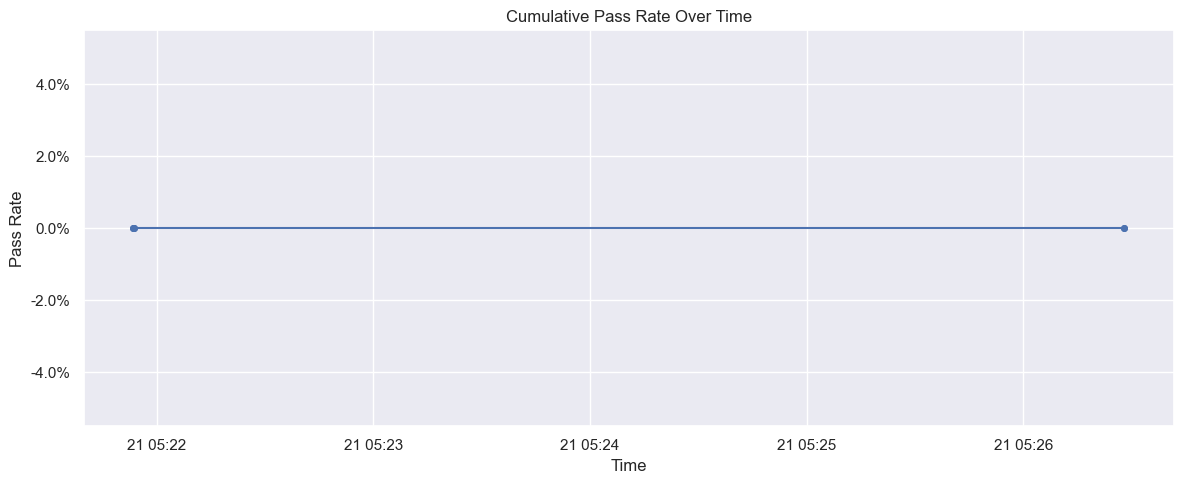

In [3]:
if len(df) > 0:
    df['created_at'] = pd.to_datetime(df['created_at'])
    df = df.sort_values('created_at')
    df['cumulative_pass_rate'] = df['qualified'].expanding().mean()

    fig, ax = plt.subplots()
    ax.plot(df['created_at'], df['cumulative_pass_rate'], marker='o', ms=4)
    ax.set_title('Cumulative Pass Rate Over Time')
    ax.set_ylabel('Pass Rate')
    ax.set_xlabel('Time')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
    plt.tight_layout()
    plt.show()
else:
    print("No data yet. Run Notebook 04 first.")

## 3. Metric distributions

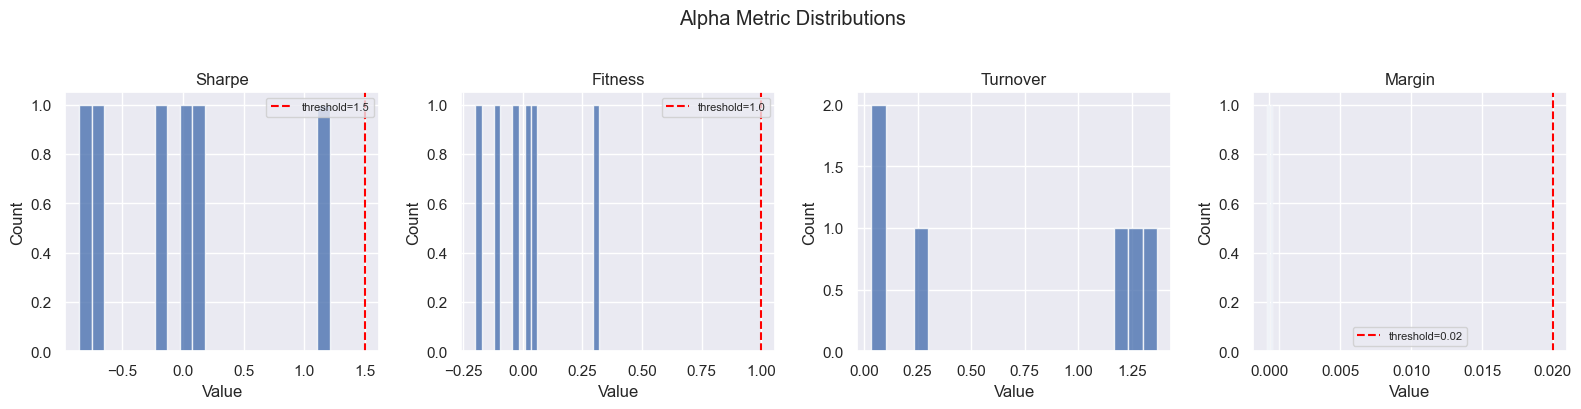

In [4]:
if len(df) > 0 and 'sharpe' in df.columns:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    metrics = ['sharpe', 'fitness', 'turnover', 'margin']
    thresholds = [1.5, 1.0, None, 0.02]

    for ax, metric, threshold in zip(axes, metrics, thresholds):
        values = df[metric].dropna()
        ax.hist(values, bins=20, edgecolor='white', alpha=0.8)
        if threshold is not None:
            ax.axvline(threshold, color='red', ls='--', label=f'threshold={threshold}')
            ax.legend(fontsize=8)
        ax.set_title(metric.capitalize())
        ax.set_xlabel('Value')
        ax.set_ylabel('Count')

    plt.suptitle('Alpha Metric Distributions', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No metric data available.")

## 4. Failure reason analysis

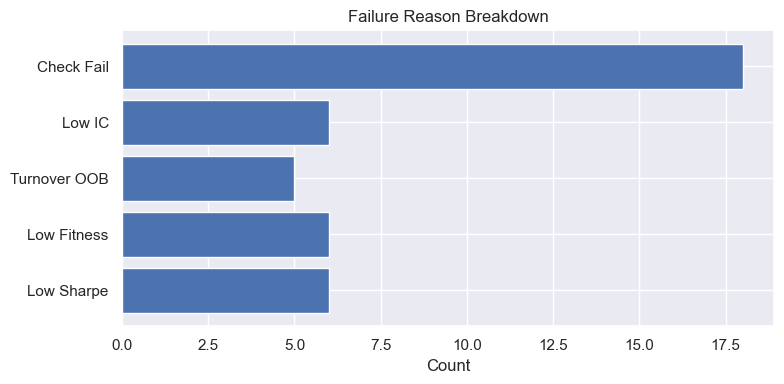

In [5]:
if len(df) > 0:
    failed_df = df[~df['qualified']]
    all_reasons = [r for reasons in failed_df['failure_reasons_list'] for r in reasons]

    if all_reasons:
        # Categorize reasons
        reason_cats = {}
        for r in all_reasons:
            if 'sharpe' in r:    cat = 'Low Sharpe'
            elif 'fitness' in r:  cat = 'Low Fitness'
            elif 'turnover' in r: cat = 'Turnover OOB'
            elif 'ic_mean' in r:  cat = 'Low IC'
            elif 'check_fail' in r: cat = 'Check Fail'
            else:                   cat = 'Other'
            reason_cats[cat] = reason_cats.get(cat, 0) + 1

        fig, ax = plt.subplots(figsize=(8, 4))
        cats = list(reason_cats.keys())
        counts = list(reason_cats.values())
        ax.barh(cats, counts)
        ax.set_title('Failure Reason Breakdown')
        ax.set_xlabel('Count')
        plt.tight_layout()
        plt.show()
    else:
        print("No failure reasons recorded yet.")
else:
    print("No data available.")

## 5. Novelty distribution

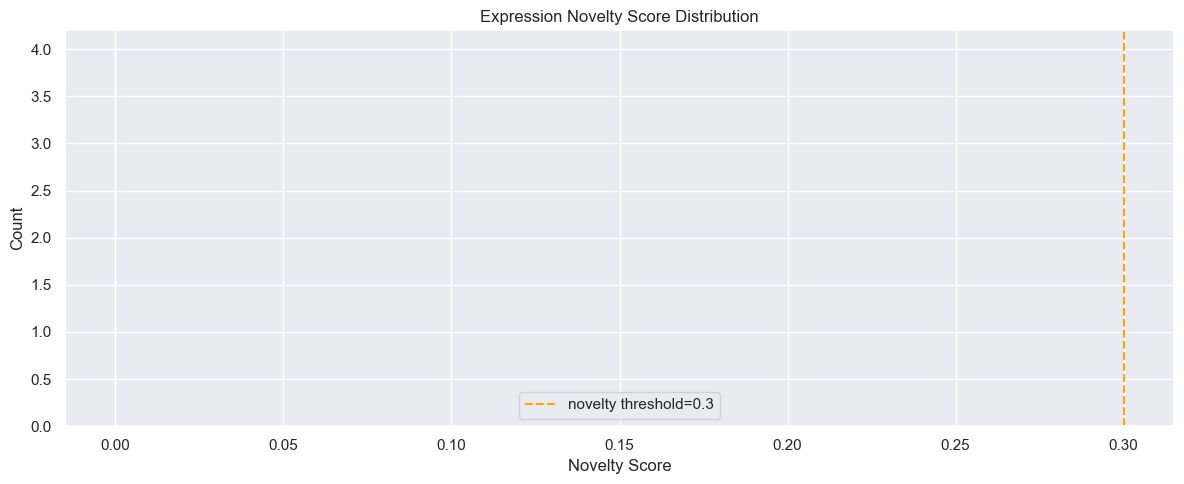

In [6]:
if len(df) > 1:
    novelty_scorer = NoveltyScorer(store, memory)
    sample = df['expression'].dropna().tolist()[:30]  # cap for speed
    scores = novelty_scorer.score_batch(sample)

    fig, ax = plt.subplots()
    ax.hist(scores, bins=15, edgecolor='white')
    ax.axvline(0.3, color='orange', ls='--', label='novelty threshold=0.3')
    ax.set_title('Expression Novelty Score Distribution')
    ax.set_xlabel('Novelty Score')
    ax.set_ylabel('Count')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Need at least 2 alphas for novelty analysis.")

## 6. Expression clustering

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


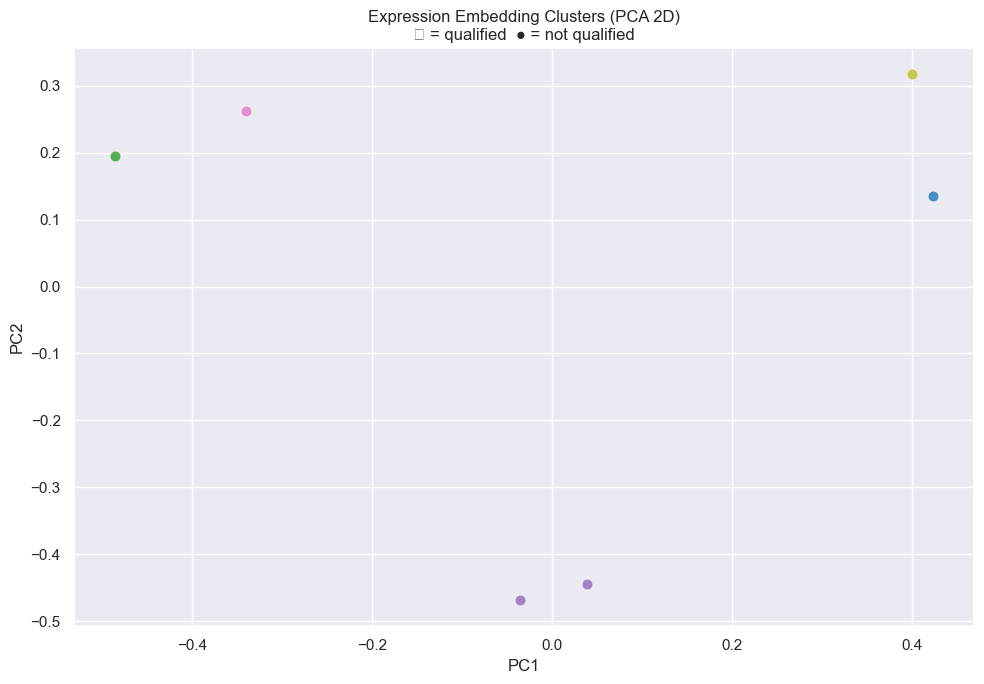

In [7]:
if len(df) >= 5:
    from sklearn.decomposition import PCA
    from sklearn.cluster import KMeans

    sample_df = df[['expression', 'qualified', 'sharpe']].dropna().head(50)
    exprs = sample_df['expression'].tolist()
    embeddings = store.embed(exprs)
    emb_arr = np.array(embeddings)

    # PCA → 2D
    pca = PCA(n_components=2)
    coords = pca.fit_transform(emb_arr)

    # K-means clustering
    n_clusters = min(5, len(exprs))
    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    labels = km.fit_predict(emb_arr)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = cm.tab10(labels / n_clusters)
    qualified_mask = sample_df['qualified'].values
    markers = ['*' if q else 'o' for q in qualified_mask]
    sizes   = [200 if q else 60 for q in qualified_mask]

    for i, (x, y, c, m, s) in enumerate(zip(coords[:, 0], coords[:, 1], colors, markers, sizes)):
        ax.scatter(x, y, c=[c], marker=m, s=s, alpha=0.8, edgecolors='white', linewidths=0.5)

    ax.set_title('Expression Embedding Clusters (PCA 2D)\n★ = qualified  ● = not qualified')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    plt.tight_layout()
    plt.show()
else:
    print("Need at least 5 alphas for clustering.")

## 7. Bandit direction performance

In [8]:
bandit_stats = bandit.stats_table()
df_bandit = pd.DataFrame(bandit_stats)

print("Bandit direction stats:")
display(df_bandit)

Bandit direction stats:


,direction,tries,wins,win_rate,ucb_score
0,cross-sectional price momentum with volume con...,0,0,0.0,∞
1,short-term reversal using intraday open-close ...,0,0,0.0,∞
2,earnings quality factors from fundamental acco...,0,0,0.0,∞
3,analyst revision momentum and earnings surpris...,0,0,0.0,∞
4,volatility regime signals using realized vs im...,0,0,0.0,∞
5,liquidity-driven cross-sectional ranking,0,0,0.0,∞
6,sector-relative valuation anomalies,0,0,0.0,∞
7,earnings yield combined with growth quality sc...,0,0,0.0,∞
8,price-to-book anomaly with leverage adjustment,0,0,0.0,∞
9,overnight vs intraday return decomposition,0,0,0.0,∞


In [9]:
# Qualified alphas summary table
qual_df = df[df['qualified'] == True][['expression', 'sharpe', 'fitness', 'turnover', 'margin', 'hypothesis']]
if len(qual_df) > 0:
    print("All qualified alphas:")
    display(qual_df.sort_values('sharpe', ascending=False))
else:
    print("No qualified alphas yet.")

No qualified alphas yet.


## 8. Skeleton Family Tree

In [10]:
# Per-skeleton stats table
skeletons = registry.all(include_archived=True)

if skeletons:
    skel_rows = []
    for sk in skeletons:
        skel_rows.append({
            "skeleton_id": sk.skeleton_id[:8],
            "template": sk.template_str[:60],
            "operators": ", ".join(sk.operators_used[:3]),
            "attempt_count": sk.attempt_count,
            "success_count": sk.success_count,
            "soft_success_count": sk.soft_success_count,
            "success_rate": f"{sk.success_rate:.0%}",
            "avg_sharpe": round(sk.avg_sharpe, 3),
            "archived": sk.archived,
        })
    df_skel = pd.DataFrame(skel_rows)
    print("Skeleton Registry — all skeletons:")
    display(df_skel)
else:
    print("No skeletons in registry yet. Run Notebook 04 with track_mode='hybrid' to populate.")

Skeleton Registry — all skeletons:


,skeleton_id,template,operators,attempt_count,success_count,soft_success_count,success_rate,avg_sharpe,archived
0,2a6d5b37,"group_rank(($X1 - $X2) / $X2, $G1)",group_rank,5,0,0,0%,0.0,False
1,3128cf7d,"group_rank(ts_std_dev($X1, $W1), $G1)","group_rank, ts_std_dev",2,0,0,0%,0.0,False
2,42aab681,"group_rank(ts_std_dev($X1, $W1) / ts_mean($X2,...","group_rank, ts_std_dev, ts_mean",0,0,0,0%,0.0,False
3,7c625474,"ts_corr($X1, abs($X2), $W1)",ts_corr,0,0,0,0%,0.0,False
4,e7c5d916,"group_rank(($X1 - ts_mean($X1, $W1)) / ts_std_...","group_rank, ts_mean, ts_std_dev",0,0,0,0%,0.0,False
5,dfe885dd,"trade_when(ts_rank(ts_std_dev($X1, $W1), $W2) ...","trade_when, ts_rank, ts_std_dev",0,0,0,0%,0.0,False
6,fded42e8,"group_rank(ts_corr($X1, $X2, $W1), $G1)","group_rank, ts_corr",0,0,0,0%,0.0,False
7,05433f5d,"regression_neut($X1, ts_std_dev($X2, $W1))","regression_neut, ts_std_dev",0,0,0,0%,0.0,False
8,4acf7ee4,"if_else(rank($X1) > $W1, $X2, -1 * $X2)","if_else, rank",0,0,0,0%,0.0,False
9,bfda36dd,"group_neutralize(rank($X1), bucket(rank(cap), ...","group_neutralize, rank, bucket",0,0,0,0%,0.0,False


In [11]:
# Skeleton family tree — link skeleton → alpha children
if len(df) > 0 and 'skeleton_id' in df.columns:
    skel_children = df[df['skeleton_id'].fillna('') != ''].groupby('skeleton_id').apply(
        lambda g: g[['id', 'expression', 'qualified', 'sharpe']].to_dict(orient='records')
    ).to_dict()

    print(f"Skeletons with alpha children: {len(skel_children)}\n")
    for sk_id, children in list(skel_children.items())[:5]:
        sk = registry.get(sk_id)
        print(f"SKELETON [{sk_id[:8]}] {sk.template_str[:70] if sk else '(not in registry)'}")
        for ch in children[:5]:
            icon = "✅" if ch['qualified'] else "❌"
            sharpe = f"sharpe={ch.get('sharpe', 0):.2f}" if ch.get('sharpe') else ""
            print(f"  {icon} {ch['expression'][:60]}  {sharpe}")
        print()
else:
    print("No skeleton_id column in alpha data or no skeleton-track alphas yet.")

Skeletons with alpha children: 2

SKELETON [2a6d5b37] group_rank(($X1 - $X2) / $X2, $G1)
  ❌ group_rank((open - close) / close, subindustry)  sharpe=1.21
  ❌ group_rank((cap - volume) / volume, sector)  sharpe=-0.15
  ❌ group_rank((volume - returns) / returns, market)  sharpe=-0.71
  ❌ group_rank((returns - open) / open, subindustry)  sharpe=-0.85

SKELETON [3128cf7d] group_rank(ts_std_dev($X1, $W1), $G1)
  ❌ group_rank(ts_std_dev(close, 50), industry)  sharpe=0.07
  ❌ group_rank(ts_std_dev(open, 100), sector)  sharpe=0.18



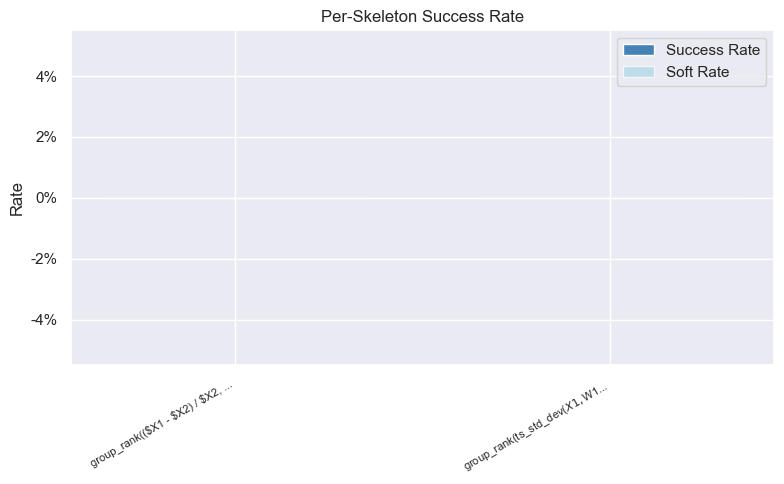

In [12]:
# Per-skeleton output distribution (bar chart of success rates)
if skeletons and any(sk.attempt_count > 0 for sk in skeletons):
    active_skel = [sk for sk in skeletons if sk.attempt_count > 0]
    labels = [sk.template_str[:30] + "..." for sk in active_skel]
    success_rates = [sk.success_rate for sk in active_skel]
    soft_rates = [sk.soft_rate for sk in active_skel]

    x = np.arange(len(active_skel))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(8, len(active_skel)*1.5), 5))
    bars1 = ax.bar(x - width/2, success_rates, width, label='Success Rate', color='steelblue')
    bars2 = ax.bar(x + width/2, soft_rates, width, label='Soft Rate', color='lightblue', alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Rate')
    ax.set_title('Per-Skeleton Success Rate')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No skeleton attempts recorded yet.")

## 9. TrackBandit Arm Curve

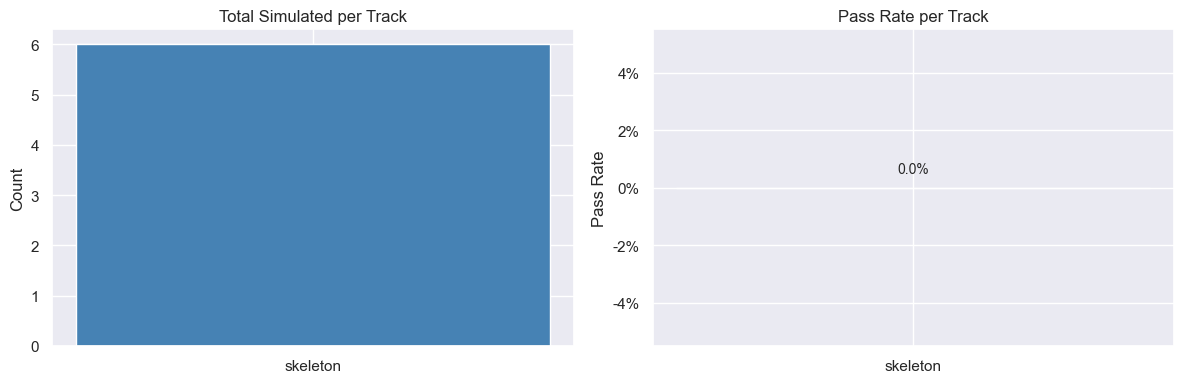

,track,total,qualified,pass_rate
0,skeleton,6,0,0.0


In [13]:
# Track comparison: explorer vs skeleton pass rates (using alpha memory data)
if len(df) > 0 and 'track' in df.columns:
    track_df = df.groupby('track').agg(
        total=('id', 'count'),
        qualified=('qualified', 'sum'),
    ).reset_index()
    track_df['pass_rate'] = track_df['qualified'] / track_df['total']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Bar chart: total simulated per track
    axes[0].bar(track_df['track'], track_df['total'], color=['steelblue', 'seagreen'])
    axes[0].set_title('Total Simulated per Track')
    axes[0].set_ylabel('Count')

    # Bar chart: pass rates
    bars = axes[1].bar(track_df['track'], track_df['pass_rate'],
                        color=['steelblue', 'seagreen'])
    for bar, rate in zip(bars, track_df['pass_rate']):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.005,
                     f'{rate:.1%}', ha='center', fontsize=10)
    axes[1].set_title('Pass Rate per Track')
    axes[1].set_ylabel('Pass Rate')
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

    plt.tight_layout()
    plt.show()
    display(track_df)
else:
    print("No track column data yet. Run Notebook 04 with dual-track mode.")

In [14]:
# Optional: release DB/file handles before switching notebooks
import gc

for obj_name in ["memory", "registry", "store", "pi"]:
    obj = globals().get(obj_name)
    close_fn = getattr(obj, "close", None)
    if callable(close_fn):
        try:
            close_fn()
            print(f"Closed: {obj_name}")
        except Exception as e:
            print(f"Failed to close {obj_name}: {e}")

for obj_name in ["memory", "registry", "store", "pi"]:
    if obj_name in globals():
        del globals()[obj_name]

gc.collect()
print("Released DB/file handles and cleared related globals.")

Closed: memory
Closed: registry
Released DB/file handles and cleared related globals.


## ✅ Notebook 05 Complete

You now have full visibility into:
- How pass rates evolve with learning
- Which metric is the bottleneck
- Which research directions are most productive (bandit stats)
- Structural diversity of generated expressions (clustering)

Use these insights to tune the prompts, adjust qualification thresholds in `.env`,
or add new research papers to the knowledge base.